In [1]:
# 基本匯入
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
from skimage import measure, morphology
from skan import Skeleton, summarize
from skan.csr import skeleton_to_nx
import networkx as nx

In [2]:
# 載入影像與標註
sample_id = "S1585-2_a"
base_path = Path("../data") / sample_id

image_path = base_path / "image.png"
label_path = base_path / "label.png"
mask_path = base_path / "mask.png"

for p in (image_path, label_path):
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

green_img = np.array(Image.open(image_path).convert("RGB"))[:, 1]
label_img = np.array(Image.open(label_path).convert("L"))
mask_img = np.array(Image.open(mask_path).convert("L")) if mask_path.exists() else None

binary_label = (label_img > 0).astype(np.uint8)
labeled = measure.label(binary_label, connectivity=1)
regions = measure.regionprops(labeled)
print(f"Regions detected: {len(regions)}")

Regions detected: 80


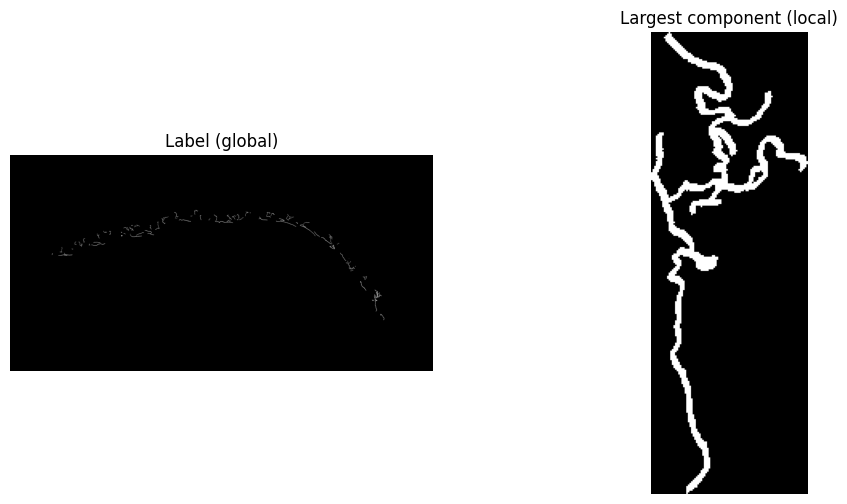

{'region_label': 77, 'area': np.float64(2858.0), 'bbox': (1787, 4848, 2077, 4946)}


In [3]:
# 選擇最大連通元件並切出局部
if len(regions) == 0:
    raise ValueError("No connected components found in label image.")

target_region = max(regions, key=lambda r: r.area)
local_mask = target_region.image.astype(np.uint8)
minr, minc, maxr, maxc = target_region.bbox

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(label_img, cmap="gray")
ax[0].set_title("Label (global)")
ax[0].axis("off")
ax[1].imshow(local_mask, cmap="gray")
ax[1].set_title("Largest component (local)")
ax[1].axis("off")
plt.show()

print({"region_label": target_region.label, "area": target_region.area, "bbox": target_region.bbox})

In [4]:
# 以 skimage 骨架化並用 skan 取得拓樸
skeleton = morphology.skeletonize(local_mask > 0).astype(np.uint8)

graph = None
branch_data = None
try:
    skel_obj = Skeleton(skeleton, keep_images=False)
    branch_data = summarize(skel_obj, separator="-")
    raw_graph = skeleton_to_nx(skel_obj, summary=branch_data)

    # 將節點從 index 重新標籤成座標 (y, x)
    mapping = {i: tuple(skel_obj.coordinates[i].astype(int)) for i in raw_graph.nodes()}
    graph = nx.relabel_nodes(raw_graph, mapping)

    # 將 branch-distance 屬性補回邊
    for _, row in branch_data.iterrows():
        src_id = int(row["node-id-src"])
        dst_id = int(row["node-id-dst"])
        branch_distance = float(row.get("branch-distance", 0.0))
        if src_id in mapping and dst_id in mapping and graph.has_edge(mapping[src_id], mapping[dst_id]):
            for k in graph[mapping[src_id]][mapping[dst_id]]:
                graph[mapping[src_id]][mapping[dst_id]][k]["branch-distance"] = branch_distance
                break  # 每對節點只需設定一次
except Exception as e:
    print(f"Skeleton build failed: {e}")
    graph = None

if graph is None or graph.number_of_nodes() == 0:
    raise RuntimeError("No skeleton graph generated.")

print({"nodes": graph.number_of_nodes(), "edges": graph.number_of_edges()})
branch_data.head() if branch_data is not None else None

{'nodes': 30, 'edges': 30}


,skeleton-id,node-id-src,node-id-dst,branch-distance,branch-type,mean-pixel-value,stdev-pixel-value,image-coord-src-0,image-coord-src-1,image-coord-dst-0,image-coord-dst-1,coord-src-0,coord-src-1,coord-dst-0,coord-dst-1,euclidean-distance
0,0,0,114,113.982756,1,1.0,0.0,2,11,53,48,2,11,53,48,63.007936
1,0,55,114,39.798990,1,1.0,0.0,37,74,53,48,37,74,53,48,30.528675
2,0,114,148,19.313708,2,1.0,0.0,53,48,64,41,53,48,64,41,13.038405
3,0,147,385,47.213203,1,1.0,0.0,64,6,105,9,64,6,105,9,41.109610
4,0,148,153,3.414214,2,1.0,0.0,64,41,65,44,64,41,65,44,3.162278


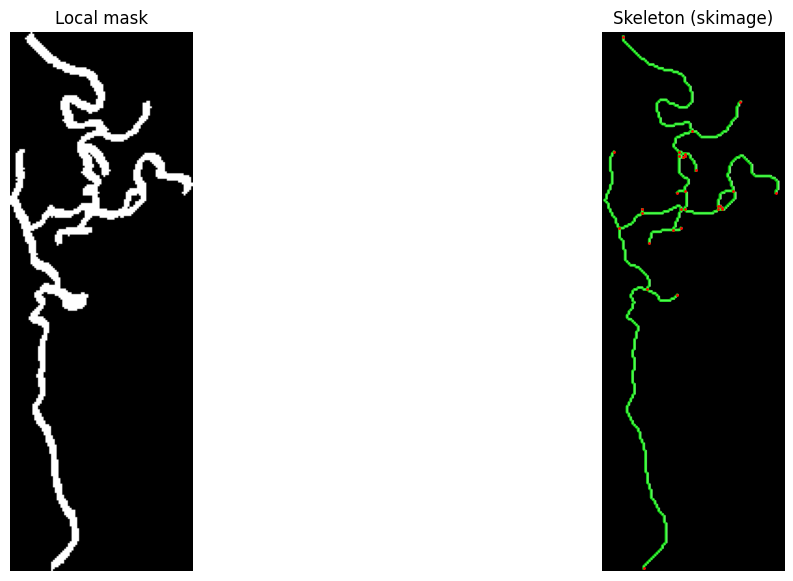

In [5]:
# 視覺化：局部骨架與節點
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
ax_local, ax_skel = axes

ax_local.imshow(local_mask, cmap="gray")
ax_local.set_title("Local mask")
ax_local.axis("off")

ax_skel.imshow(skeleton, cmap="gray")
ax_skel.set_title("Skeleton (skimage)")
ax_skel.axis("off")

# 將節點/邊繪在 skeleton 上
for u, v, data in graph.edges(data=True):
    path = data.get("path", [])
    all_x = [p[1] for p in path]
    all_y = [p[0] for p in path]
    ax_skel.plot(all_x, all_y, color="lime", linewidth=2, alpha=0.7)

for (y, x) in graph.nodes():
    ax_skel.plot(x, y, "ro", markersize=1)

plt.show()

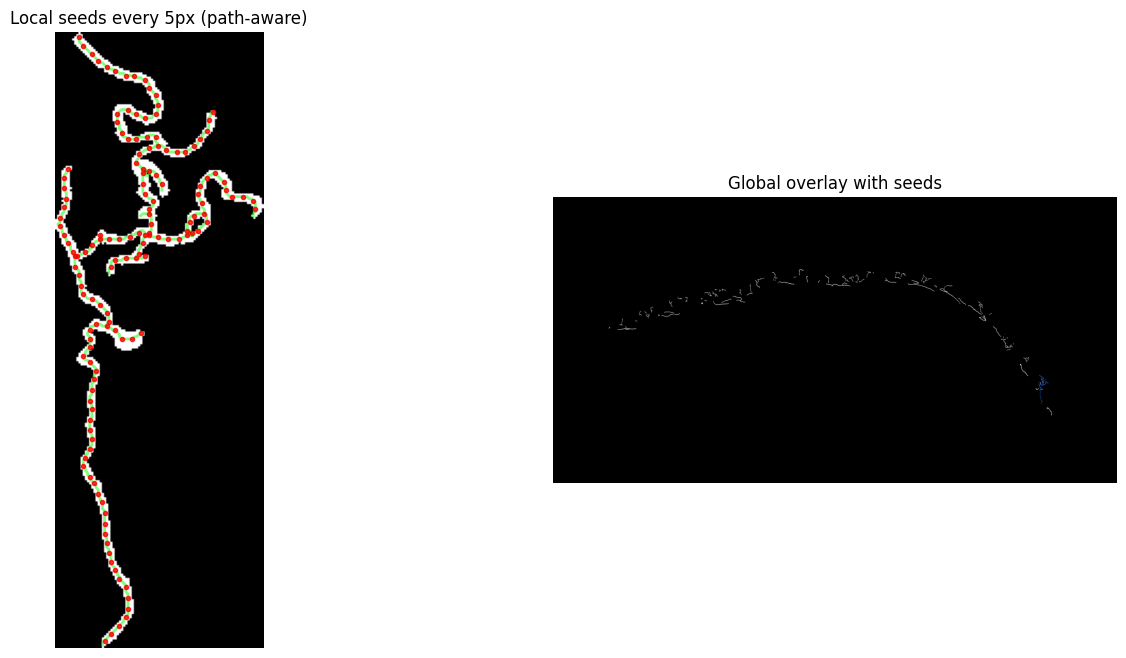

Seeds placed: 147 (spacing=5.0px)


In [7]:
# 視覺化：沿 path 依距離取樣（每 5px）並映射回全域
seed_spacing = 5.0
seed_points_local = []

def interpolate_along_path(coords: np.ndarray, spacing: float):
    """給定 polyline 座標 (N,2)，每 spacing 取樣點，回傳 (y,x) 列表。"""
    if coords.shape[0] < 2:
        return []
    diffs = np.diff(coords, axis=0)
    seg_len = np.linalg.norm(diffs, axis=1)
    cum_len = np.concatenate([[0.0], np.cumsum(seg_len)])
    total = cum_len[-1]
    if total <= 0:
        return []
    samples = np.arange(0.0, total + 1e-6, spacing)
    pts = []
    for s in samples:
        idx = np.searchsorted(cum_len, s, side="right") - 1
        idx = np.clip(idx, 0, len(seg_len) - 1)
        t = (s - cum_len[idx]) / (seg_len[idx] + 1e-8)
        pt = coords[idx] + t * diffs[idx]
        pts.append(tuple(pt))
    return pts

# 安全取得 path（避免 numpy array 直接做 truthy 判斷）
def get_path(data: dict, u, v):
    path = data.get("path", None)
    if path is None or (hasattr(path, "__len__") and len(path) == 0):
        path = data.get("path-coordinates", None)
    if path is None or (hasattr(path, "__len__") and len(path) == 0):
        path = np.array([u, v], dtype=float)
    return np.asarray(path, dtype=float)

# 逐邊取 path，依累積距離決定種子位置
for u, v, data in graph.edges(data=True):
    coords = get_path(data, u, v)
    seed_points_local.extend(interpolate_along_path(coords, seed_spacing))

# 去重（四捨五入到最近像素）
seed_points_local_unique = list({(int(round(y)), int(round(x))) for y, x in seed_points_local})

def local_to_global(coord):
    y, x = coord
    return y + minr, x + minc

overlay = cv2.cvtColor(label_img.copy(), cv2.COLOR_GRAY2BGR)
for u, v, data in graph.edges(data=True):
    coords = get_path(data, u, v)
    if coords.shape[0] < 2:
        continue
    for p0, p1 in zip(coords[:-1], coords[1:]):
        y0, x0 = local_to_global(p0)
        y1, x1 = local_to_global(p1)
        cv2.line(overlay, (int(round(x0)), int(round(y0))), (int(round(x1)), int(round(y1))), (0, 255, 0), 2)

for (y, x) in seed_points_local_unique:
    gy, gx = local_to_global((y, x))
    cv2.circle(overlay, (gx, gy), 2, (0, 0, 255), -1)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
ax_local, ax_global = axes
ax_local.imshow(local_mask, cmap="gray")
ax_local.set_title("Local seeds every 5px (path-aware)")
ax_local.axis("off")

# 局部：畫整條 path
for u, v, data in graph.edges(data=True):
    coords = get_path(data, u, v)
    if coords.shape[0] < 2:
        continue
    ax_local.plot(coords[:, 1], coords[:, 0], color="lime", linewidth=2, alpha=0.5)

if seed_points_local_unique:
    ys, xs = zip(*seed_points_local_unique)
    ax_local.plot(xs, ys, "ro", markersize=3, alpha=0.8)

ax_global.imshow(overlay)
ax_global.set_title("Global overlay with seeds")
ax_global.axis("off")
plt.show()

print(f"Seeds placed: {len(seed_points_local_unique)} (spacing={seed_spacing}px)")

In [ ]:
# 簡要統計：邊長與節點度數
import pandas as pd
from collections import Counter

edges_len = [d.get("branch-distance", 0.0) for _, _, d in graph.edges(data=True)]
nodes_deg = [graph.degree(n) for n in graph.nodes()]

print("Edge length stats (pixels):", pd.Series(edges_len).describe())
print("Node degree counts:", Counter(nodes_deg))